In [1]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole 
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import Draw
import io
from PIL import Image

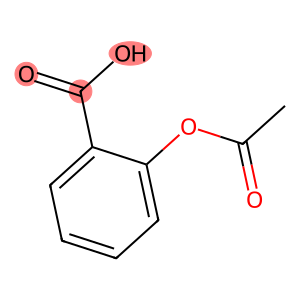

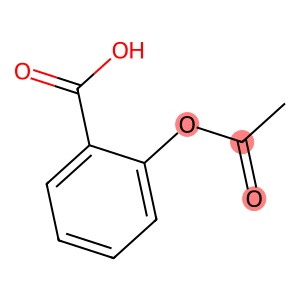

In [2]:
# 筛查分子内特定结构
m = Chem.MolFromSmiles('c1cc(C(=O)O)c(OC(=O)C)cc1')
substructure = Chem.MolFromSmarts('C(=O)O') # 筛选所有的酯键
matches = m.GetSubstructMatches(substructure)
for match in matches:
    img = Draw.MolToImage(m, highlightAtoms=list(match))
    display(img)

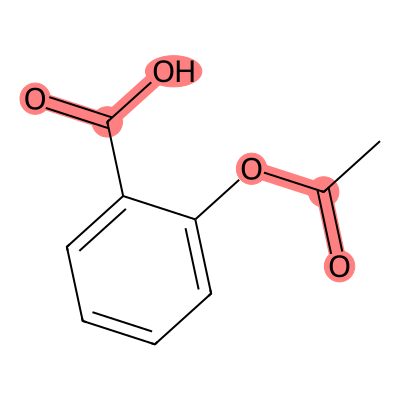

In [3]:
# 高亮显示（合并版）
all_highlighted = []
for match in matches:
    all_highlighted.extend(match)

drawer = rdMolDraw2D.MolDraw2DCairo(400, 400)
drawer.DrawMolecule(m, highlightAtoms=list(set(all_highlighted)))
drawer.FinishDrawing()
bio = io.BytesIO(drawer.GetDrawingText())
Image.open(bio)


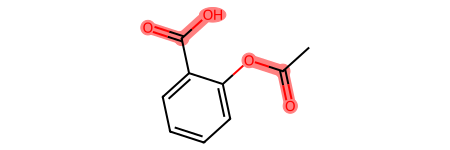

In [4]:
# 另一种合并版，简单一点
m.__sssAtoms = matches 
m

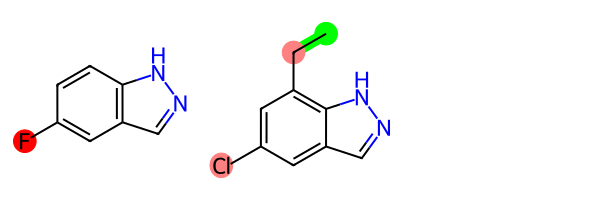

In [5]:
# 找到两个分子的MCS，并高亮差异之处
from rdkit.Chem import rdFMCS
from rdkit.Chem.Draw import rdDepictor
rdDepictor.SetPreferCoordGen(True) # 都给我站直了

mol1 = Chem.MolFromSmiles('FC1=CC=C2C(=C1)C=NN2')
mol2 = Chem.MolFromSmiles('CCC1=C2NN=CC2=CC(Cl)=C1')

def view_difference(mol1, mol2):
    mcs = rdFMCS.FindMCS([mol1,mol2]) # 内置函数，寻找最大公共子结构 Maximum Common Substructure
    mcs_mol = Chem.MolFromSmarts(mcs.smartsString)

    match1 = mol1.GetSubstructMatch(mcs_mol)
    target_atm1 = []
    for atom in mol1.GetAtoms():
        if atom.GetIdx() not in match1:
            target_atm1.append(atom.GetIdx())

    match2 = mol2.GetSubstructMatch(mcs_mol)
    target_atm2 = []
    for atom in mol2.GetAtoms():
        if atom.GetIdx() not in match2:
            target_atm2.append(atom.GetIdx())

    return Draw.MolsToGridImage(
        [mol1, mol2],
        highlightAtomLists=[target_atm1, target_atm2],
        highlightAtomColors=[{0: (1,0,0)}, {0: (0,1,0)}] # 要求dict格式
    )

view_difference(mol1,mol2)

((2,), (3,), (4,), (5,), (6,), (8,), (9,), (10,), (11,), (12,), (13,), (14,), (15,), (17,))


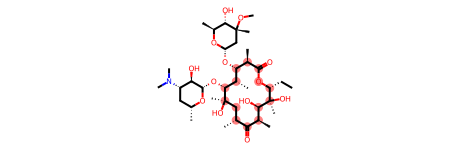

In [6]:
# 寻找分子中的特定环
erythromycin = Chem.MolFromSmiles("CC[C@@H]1[C@@]([C@@H]([C@H](C(=O)[C@@H](C[C@@]([C@@H]([C@H]([C@@H]([C@H](C(=O)O1)C)O[C@H]2C[C@@]([C@H]([C@@H](O2)C)O)(C)OC)C)O[C@H]3[C@@H]([C@H](C[C@H](O3)C)N(C)C)O)(C)O)C)C)O)(C)O")
macro = Chem.MolFromSmarts("[r{12-}]") # 匹配环上原子+环大小≥12
print(erythromycin.GetSubstructMatches(macro))
erythromycin

In [7]:
# 优化一般查询GetSubstructMatch中会把环和线形混为一谈的问题：精确索引
def get_match_bond_indices(query, mol, match_atom_indices):
    bond_indices = []
    for query_bond in query.GetBonds():
        atom_index1 = match_atom_indices[query_bond.GetBeginAtomIdx()]
        atom_index2 = match_atom_indices[query_bond.GetEndAtomIdx()]
        bond_indices.append(mol.GetBondBetweenAtoms(
             atom_index1, atom_index2).GetIdx())
    return bond_indices # 建立键索引列表传给原Match函数

pat = Chem.MolFromSmarts("*~*~*~*") # 要求找到四个线形连接原子
mol = Chem.MolFromSmiles("C1CCC1") # 四元环
atom_indices = mol.GetSubstructMatch(pat)
bond_indices = get_match_bond_indices(pat, mol, atom_indices)
print(Chem.MolFragmentToSmiles(mol, atom_indices, bond_indices))

CCCC


matched atom indices: [0, 1, 2, 3]
matched bond indices: [0, 1, 2]


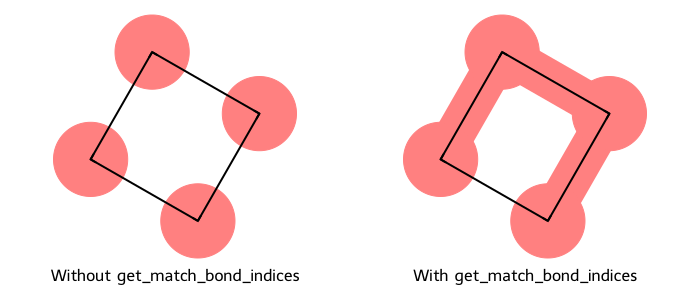

In [8]:
# 对比：仅使用原子匹配 vs. 同时使用精确的匹配键索引
print(f"matched atom indices: {list(atom_indices)}")
print(f"matched bond indices: {list(bond_indices)}")

comparison = Draw.MolsToGridImage(
    [mol, mol],
    molsPerRow=2,
    subImgSize=(350, 300),
    legends=[
        "Without get_match_bond_indices",
        "With get_match_bond_indices",
    ],
    highlightAtomLists=[list(atom_indices), list(atom_indices)],
    # 左图不传匹配键索引；右图只高亮查询中的三条键
    highlightBondLists=[None, list(bond_indices)],
)
comparison